# Exploratory Data Analisys

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Primera vista de datos

Carga

In [2]:
ROUTE_DATA = rf"../data/raw/Churn_Modelling.csv"

In [3]:
df = pd.read_csv(ROUTE_DATA)

Head

In [4]:
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

Describe

In [ ]:
print(df.describe())

Cantidad de nulos por columna

In [6]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Columnas que son str

In [7]:
for col in df.columns:
    if df[col].dtype == "object":
        print(df[col])

0        Hargrave
1            Hill
2            Onio
3            Boni
4        Mitchell
          ...    
9995     Obijiaku
9996    Johnstone
9997          Liu
9998    Sabbatini
9999       Walker
Name: Surname, Length: 10000, dtype: object
0        France
1         Spain
2        France
3        France
4         Spain
         ...   
9995     France
9996     France
9997     France
9998    Germany
9999     France
Name: Geography, Length: 10000, dtype: object
0       Female
1       Female
2       Female
3       Female
4       Female
         ...  
9995      Male
9996      Male
9997    Female
9998      Male
9999    Female
Name: Gender, Length: 10000, dtype: object


## Comprensión de datos mediante gráficas

Text(0.5, 1.0, 'Edades')

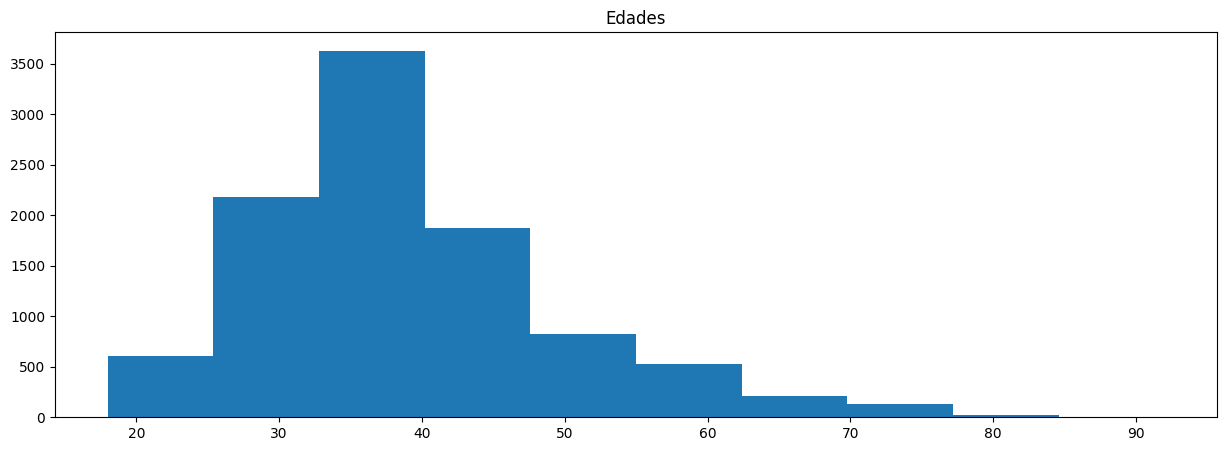

In [9]:
plt.figure(figsize=(15, 5))
plt.hist(
    df["Age"]
)

plt.title("Edades")

Cantidad que se van vs los que se quedan

In [10]:
exited_count = df["Exited"].value_counts()

In [13]:
print(exited_count)

Exited
0    7963
1    2037
Name: count, dtype: int64


<BarContainer object of 2 artists>

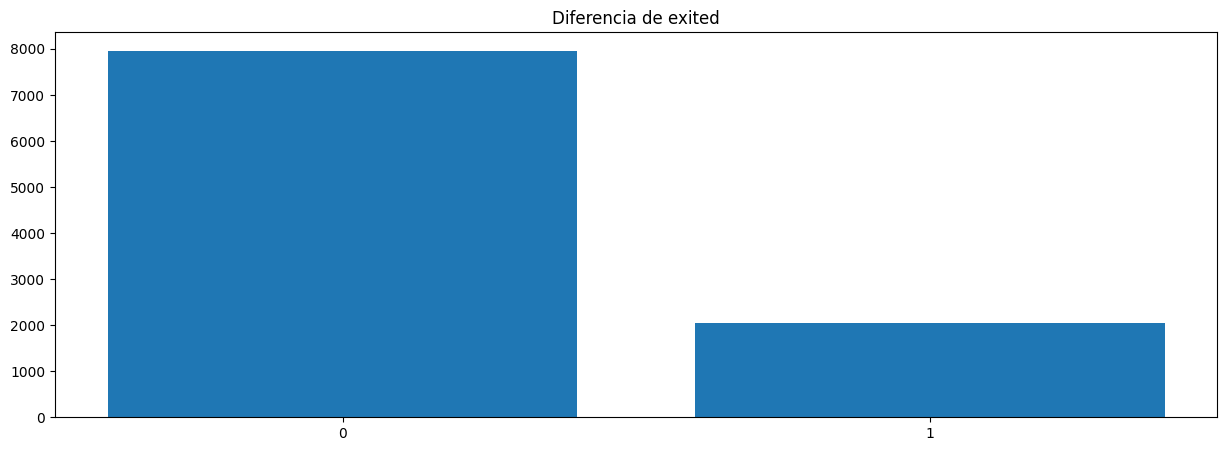

In [18]:
plt.figure(figsize=(15, 5))
plt.title("Diferencia de exited")
plt.xticks([0, 1])

plt.bar(
    exited_count.index,
    exited_count.values
)


Exited por país

In [20]:
exited_x_geography = df.groupby("Geography")["Exited"].value_counts()

In [21]:
print(exited_x_geography)

Geography  Exited
France     0         4204
           1          810
Germany    0         1695
           1          814
Spain      0         2064
           1          413
Name: count, dtype: int64


In [24]:
df_exited_x_geography = exited_x_geography.unstack()

In [25]:
print(df_exited_x_geography)

Exited        0    1
Geography           
France     4204  810
Germany    1695  814
Spain      2064  413


<Axes: xlabel='Geography'>

<Figure size 1500x500 with 0 Axes>

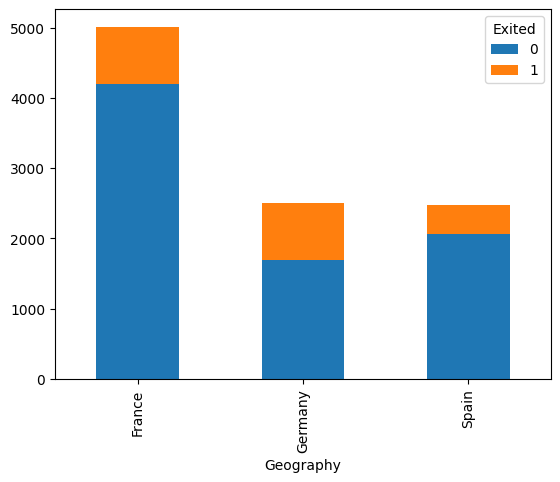

In [27]:
plt.figure(figsize=(15, 5))


df_exited_x_geography.plot(
    kind="bar",
    stacked=True
)


Text(0.5, 1.0, 'Spain')

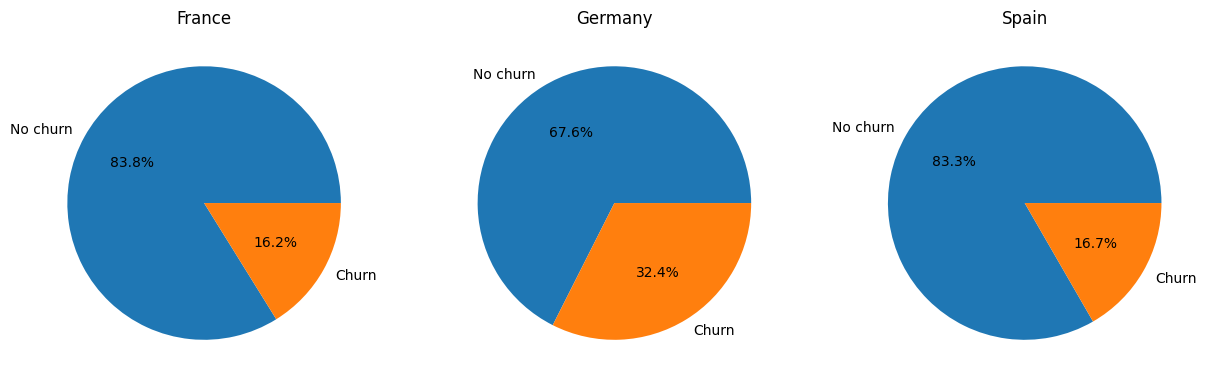

In [39]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(15, 5))

axs1 = axs[0]
axs2 = axs[1]
axs3 = axs[2]

axs1.pie(
    df_exited_x_geography.loc["France"],
    labels=["No churn", "Churn"],
    autopct="%1.1f%%"
)
axs1.set_title("France")

axs2.pie(
    df_exited_x_geography.loc["Germany"],
    labels=["No churn", "Churn"],
    autopct="%1.1f%%"
)
axs2.set_title("Germany")

axs3.pie(
    df_exited_x_geography.loc["Spain"],
    labels=["No churn", "Churn"],
    autopct="%1.1f%%"
)
axs3.set_title("Spain")